# Projeto Final – Trilha Inteligência Artificial

## Previsão de Cancelamento de Reservas em Hotéis

**Aluno:** Cinara Fernandes Skieresz

**Julho/2026**

**Curso:** Carreira Tech – Trilha Inteligência Artificial

**Ferramentas utilizadas:** Python, Pandas, NumPy, Matplotlib, Seaborn e Scikit-learn.

# Projeto de Inteligência Artificial

## Predição de Cancelamento de Reservas em Hotéis

### Carreira Tech – Trilha Inteligência Artificial

---

### Objetivo

Este projeto tem como objetivo analisar o conjunto de dados **Hotel Booking Demand** e desenvolver um modelo de Machine Learning capaz de prever o cancelamento de reservas em hotéis.

Para isso serão realizadas as seguintes etapas:

- Importação das bibliotecas
- Carregamento do dataset
- Exploração inicial
- Tratamento dos dados
- Análise Exploratória (EDA)
- Construção do modelo de Machine Learning
- Avaliação dos resultados
- Conclusão

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

print("✅ Bibliotecas importadas com sucesso!")

✅ Bibliotecas importadas com sucesso!


In [ ]:
# ============================================================
# CARREGAMENTO DO DATASET
# ============================================================

arquivo = "hotel_bookings.csv"

df = pd.read_csv(arquivo)

print("✅ Dataset carregado com sucesso!")

print(f"\nLinhas : {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")

✅ Dataset carregado com sucesso!

Linhas : 119390
Colunas: 32


In [ ]:
# ============================================================
# PRIMEIRA VISUALIZAÇÃO
# ============================================================

display(df.head())

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [ ]:
# ============================================================
# DIMENSÃO DO DATASET
# ============================================================

print("Dimensão do conjunto de dados:")

display(df.shape)

Dimensão do conjunto de dados:


(119390, 32)

In [ ]:
# ============================================================
# ESTRUTURA DO DATASET
# ============================================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [ ]:
# ============================================================
# VISUALIZAÇÃO DAS ÚLTIMAS LINHAS
# ============================================================

display(df.tail())

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
119385,City Hotel,0,23,2017,August,35,30,2,5,2,0.0,0,BB,BEL,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,0.0,0,BB,FRA,Online TA,TA/TO,0,0,0,E,E,0,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,0.0,0,BB,DEU,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07
119389,City Hotel,0,205,2017,August,35,29,2,7,2,0.0,0,HB,DEU,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,9.0,NaN,0,Transient,151.20,0,2,Check-Out,2017-09-07


In [ ]:
# ============================================================
# AMOSTRA ALEATÓRIA
# ============================================================

display(df.sample(5, random_state=42))

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
30946,Resort Hotel,0,203,2016,December,49,2,2,5,2,0.0,0,BB,GBR,Direct,Direct,0,0,0,F,F,4,No Deposit,250.0,NaN,0,Transient,66.8,0,0,Check-Out,2016-12-09
40207,City Hotel,1,82,2015,July,29,16,0,3,2,0.0,0,BB,PRT,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,9.0,NaN,0,Transient,76.5,0,0,Canceled,2015-07-16
103708,City Hotel,0,25,2016,December,53,27,0,3,3,0.0,0,BB,BRA,Offline TA/TO,TA/TO,0,0,0,A,K,2,No Deposit,220.0,NaN,0,Transient-Party,60.0,0,1,Check-Out,2016-12-30
85144,City Hotel,0,1,2016,March,11,9,0,1,1,0.0,0,BB,SWE,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,9.0,NaN,0,Transient-Party,95.0,0,0,Check-Out,2016-03-10
109991,City Hotel,0,70,2017,April,16,16,2,2,2,0.0,0,SC,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,9.0,NaN,0,Transient,108.0,0,0,Check-Out,2017-04-20


In [ ]:
# ============================================================
# ESTATÍSTICAS DESCRITIVAS
# ============================================================

display(df.describe())

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [ ]:
# ============================================================
# VARIÁVEIS CATEGÓRICAS
# ============================================================

display(df.describe(include="object"))

,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status,reservation_status_date
count,119390,119390,119390,118902,119390,119390,119390,119390,119390,119390,119390,119390
unique,2,12,5,177,8,5,10,12,3,4,3,926
top,City Hotel,August,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,Check-Out,2015-10-21
freq,79330,13877,92310,48590,56477,97870,85994,74053,104641,89613,75166,1461


In [ ]:
# ============================================================
# TIPOS DAS VARIÁVEIS
# ============================================================

display(df.dtypes)

,0
hotel,object
is_canceled,int64
lead_time,int64
arrival_date_year,int64
arrival_date_month,object
arrival_date_week_number,int64
arrival_date_day_of_month,int64
stays_in_weekend_nights,int64
stays_in_week_nights,int64
adults,int64


In [ ]:
# ============================================================
# VALORES AUSENTES
# ============================================================

valores_nulos = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

valores_nulos = valores_nulos[valores_nulos > 0]

display(valores_nulos.to_frame("Quantidade"))

,Quantidade
company,112593
agent,16340
country,488
children,4


In [ ]:
# ============================================================
# REGISTROS DUPLICADOS
# ============================================================

duplicados = df.duplicated().sum()

print(f"Quantidade de registros duplicados: {duplicados}")

Quantidade de registros duplicados: 31994


# Primeiras conclusões

Após a exploração inicial do conjunto de dados, foi possível identificar alguns pontos importantes:

- O dataset possui 119.390 registros distribuídos em 32 variáveis.
- Algumas colunas apresentam valores ausentes, principalmente `company`, `agent`, `country` e `children`.
- A coluna `company` possui uma quantidade muito elevada de valores ausentes, indicando que provavelmente não será útil para a modelagem.
- Foram identificados registros considerados duplicados, porém essa informação será analisada antes de qualquer remoção, evitando eliminar observações que possam representar reservas distintas.

Essas verificações permitem planejar o tratamento dos dados de forma mais consciente antes da etapa de análise exploratória e da construção do modelo de Machine Learning.

# Tratamento dos Dados

Após explorar o conjunto de dados, foram identificadas algumas inconsistências que precisam ser tratadas antes da análise exploratória e da construção do modelo de Machine Learning.

As principais ações realizadas nesta etapa serão:

- Tratamento dos valores ausentes;
- Remoção de uma coluna com grande quantidade de dados faltantes;
- Conversão do tipo da coluna de datas;
- Verificação da qualidade final do conjunto de dados.

In [ ]:
# ============================================================
# TRATAMENTO DOS VALORES AUSENTES
# ============================================================

# Crianças sem informação
df["children"] = df["children"].fillna(0)

# País não informado
df["country"] = df["country"].fillna("Unknown")

# Reservas sem agente
df["agent"] = df["agent"].fillna(0)

print("Tratamento dos valores ausentes concluído.")

Tratamento dos valores ausentes concluído.


In [ ]:
# ============================================================
# REMOÇÃO DA COLUNA COMPANY
# ============================================================

df.drop(columns=["company"], inplace=True)

print("Coluna 'company' removida com sucesso.")

Coluna 'company' removida com sucesso.


In [ ]:
# ============================================================
# CONVERSÃO DA DATA
# ============================================================

df["reservation_status_date"] = pd.to_datetime(
    df["reservation_status_date"]
)

print("Conversão realizada com sucesso.")

Conversão realizada com sucesso.


In [ ]:
# ============================================================
# VERIFICAÇÃO FINAL DOS VALORES AUSENTES
# ============================================================

valores_nulos = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

display(
    valores_nulos[valores_nulos > 0]
)

,0


In [ ]:
# ============================================================
# CONFERÊNCIA DOS TIPOS DAS VARIÁVEIS
# ============================================================

display(df.dtypes)

,0
hotel,object
is_canceled,int64
lead_time,int64
arrival_date_year,int64
arrival_date_month,object
arrival_date_week_number,int64
arrival_date_day_of_month,int64
stays_in_weekend_nights,int64
stays_in_week_nights,int64
adults,int64


# Conclusão da etapa

Após o tratamento dos dados, o conjunto está mais preparado para as análises seguintes.

As principais ações realizadas foram:

- preenchimento dos valores ausentes;
- remoção da coluna `company`, devido à grande quantidade de informações faltantes;
- conversão da coluna de datas para o formato `datetime`.

Essas modificações tornam o conjunto de dados mais consistente para a análise exploratória e para o treinamento do modelo de Machine Learning.

In [8]:
import os

for raiz, pastas, arquivos in os.walk("/content/drive"):
    for arquivo in arquivos:
        if "hotel" in arquivo.lower():
            print(os.path.join(raiz, arquivo))

In [10]:
from google.colab import files

uploaded = files.upload()

Saving hotel_bookings.csv to hotel_bookings.csv


In [11]:
import os
print(os.listdir())

['.config', 'hotel_bookings.csv', 'drive', 'sample_data']


In [12]:
import pandas as pd

df = pd.read_csv("hotel_bookings.csv")

print("Dataset carregado com sucesso!")
print(df.shape)

Dataset carregado com sucesso!
(119390, 32)


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [14]:
df = pd.read_csv("hotel_bookings.csv")

In [15]:
# Valores ausentes
df["children"] = df["children"].fillna(0)
df["country"] = df["country"].fillna("Unknown")
df["agent"] = df["agent"].fillna(0)

# Remover coluna company
df.drop(columns=["company"], inplace=True)

# Converter data
df["reservation_status_date"] = pd.to_datetime(df["reservation_status_date"])

# Ajustar tipos
df["children"] = df["children"].astype(int)
df["agent"] = df["agent"].astype(int)

print("Tratamento concluído!")

Tratamento concluído!


In [40]:
# Verificação de outliers em lead_time

Q1 = df["lead_time"].quantile(0.25)
Q3 = df["lead_time"].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df[
    (df["lead_time"] < limite_inferior) |
    (df["lead_time"] > limite_superior)
]

print(f"Quantidade de outliers: {len(outliers)}")

Quantidade de outliers: 3005


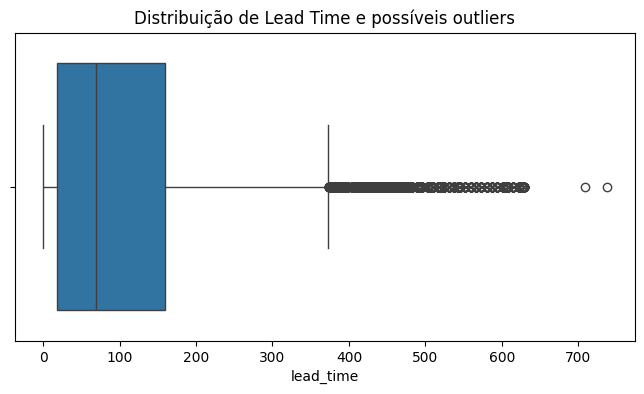

In [41]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["lead_time"])
plt.title("Distribuição de Lead Time e possíveis outliers")
plt.show()

Análise de Outliers

Foi realizada a identificação de possíveis outliers na variável lead_time
utilizando o método IQR e visualização por boxplot.

Os valores extremos foram mantidos no conjunto de dados por representarem
reservas reais feitas com grande antecedência, situação plausível no
contexto hoteleiro.

# Análise Exploratória dos Dados (EDA)

Nesta etapa serão realizadas análises gráficas para compreender o comportamento das reservas e identificar fatores que podem estar relacionados ao cancelamento.

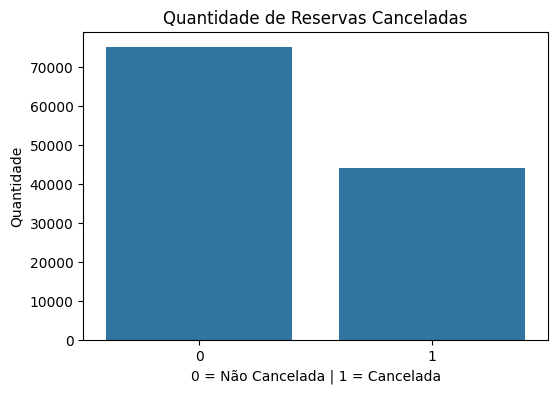

In [16]:
# ============================================================
# GRÁFICO 1 - CANCELAMENTO DAS RESERVAS
# ============================================================

plt.figure(figsize=(6,4))

sns.countplot(data=df, x="is_canceled")

plt.title("Quantidade de Reservas Canceladas")
plt.xlabel("0 = Não Cancelada | 1 = Cancelada")
plt.ylabel("Quantidade")

plt.show()

In [17]:
percentual = (
    df["is_canceled"]
      .value_counts(normalize=True)
      .sort_index()*100
)

print(percentual)

is_canceled
0    62.958372
1    37.041628
Name: proportion, dtype: float64


### Interpretação

Observa-se que uma parcela significativa das reservas foi cancelada. Esse comportamento justifica a utilização de técnicas de Machine Learning para prever cancelamentos futuros.

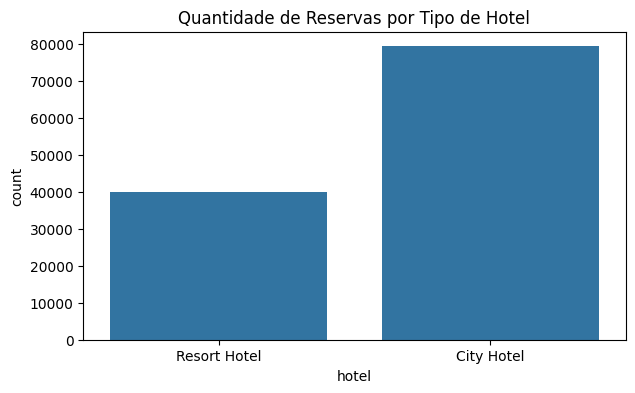

In [18]:
plt.figure(figsize=(7,4))

sns.countplot(data=df, x="hotel")

plt.title("Quantidade de Reservas por Tipo de Hotel")

plt.show()

### Interpretação

O conjunto de dados apresenta reservas em dois tipos de hotéis: City Hotel e Resort Hotel. A distribuição permite verificar qual categoria concentra maior número de reservas.

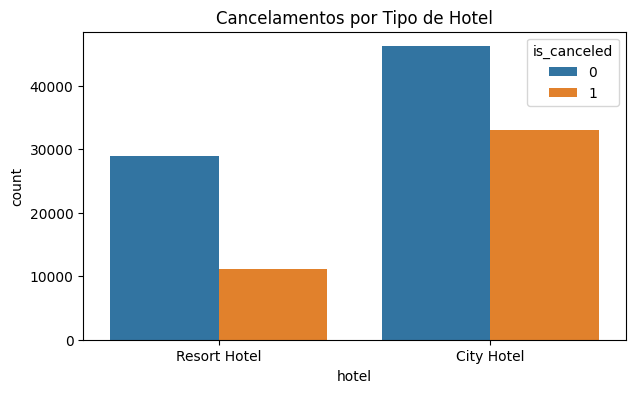

In [19]:
plt.figure(figsize=(7,4))

sns.countplot(
    data=df,
    x="hotel",
    hue="is_canceled"
)

plt.title("Cancelamentos por Tipo de Hotel")

plt.show()

### Interpretação

Comparando os dois tipos de hotéis, é possível observar diferenças na quantidade de cancelamentos, indicando que o tipo de estabelecimento pode influenciar esse comportamento.

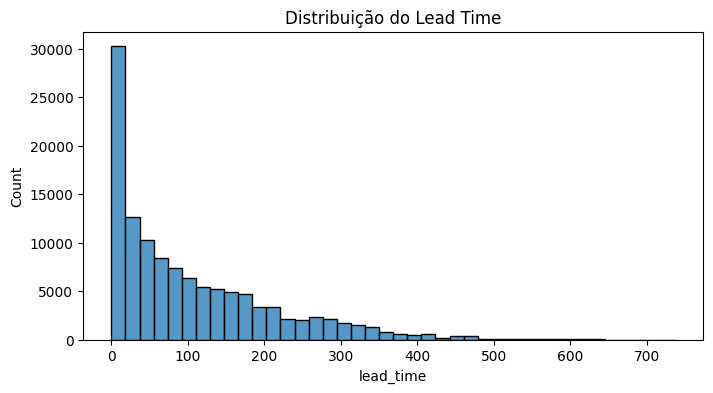

In [20]:
plt.figure(figsize=(8,4))

sns.histplot(
    data=df,
    x="lead_time",
    bins=40
)

plt.title("Distribuição do Lead Time")

plt.show()

### Interpretação

O Lead Time representa o número de dias entre a realização da reserva e a chegada do cliente. Reservas feitas com muita antecedência podem apresentar maior probabilidade de cancelamento.

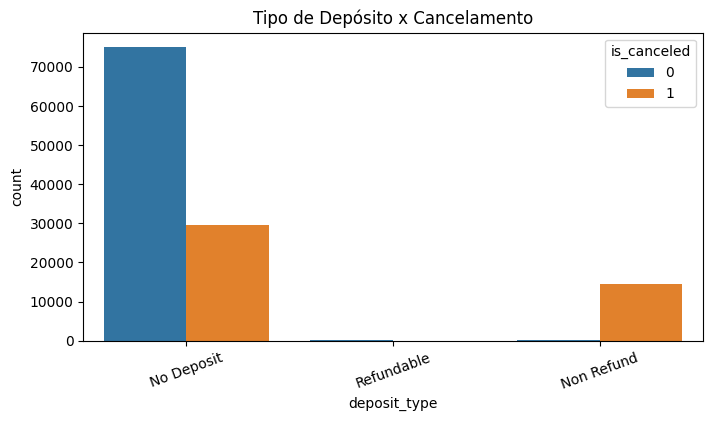

In [21]:
plt.figure(figsize=(8,4))

sns.countplot(
    data=df,
    x="deposit_type",
    hue="is_canceled"
)

plt.title("Tipo de Depósito x Cancelamento")

plt.xticks(rotation=20)

plt.show()

### Interpretação

O tipo de depósito pode influenciar diretamente a decisão do cliente em cancelar uma reserva. Observa-se uma diferença no comportamento de cancelamento entre os tipos de depósito, sugerindo que essa variável pode influenciar a ocorrência de cancelamentos.

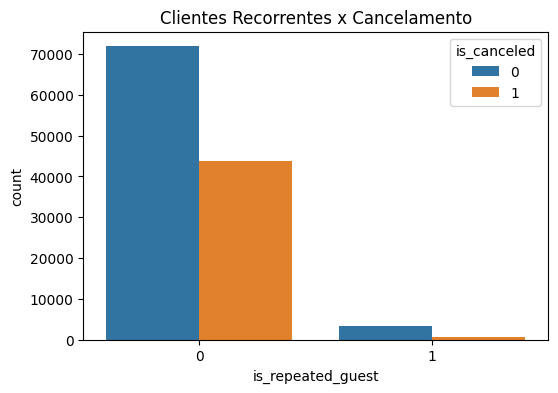

In [22]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="is_repeated_guest",
    hue="is_canceled"
)

plt.title("Clientes Recorrentes x Cancelamento")

plt.show()

## Análises utilizando filtros e agrupamentos

Além das visualizações gráficas, foram realizadas análises utilizando filtros e agrupamentos (GroupBy), permitindo compreender melhor o comportamento das reservas e identificar padrões relevantes no conjunto de dados.

### Interpretação

O gráfico sugere uma diferença no comportamento de cancelamento entre clientes recorrentes e não recorrentes, indicando uma possível relação que pode ser explorada na modelagem.

In [35]:
# ============================================================
# TAXA DE CANCELAMENTO POR TIPO DE HOTEL
# ============================================================

cancelamentos_hotel = (
    df.groupby("hotel")["is_canceled"]
      .mean()
      .sort_values(ascending=False)
)

cancelamentos_hotel = (cancelamentos_hotel * 100).round(2)

print("Taxa média de cancelamento por tipo de hotel (%)")
display(cancelamentos_hotel)

Taxa média de cancelamento por tipo de hotel (%)


,is_canceled
hotel,
City Hotel,41.73
Resort Hotel,27.76


### Interpretação

Observa-se que a taxa média de cancelamento apresenta diferenças entre os tipos de hotel, indicando que essa variável pode influenciar o comportamento das reservas e ser relevante para o modelo preditivo.

In [36]:
# ============================================================
# LEAD TIME MÉDIO POR TIPO DE HOTEL
# ============================================================

lead_time = (
    df.groupby("hotel")["lead_time"]
      .mean()
      .round(2)
)

print("Lead Time médio por tipo de hotel")
display(lead_time)

Lead Time médio por tipo de hotel


,lead_time
hotel,
City Hotel,109.74
Resort Hotel,92.68


### Interpretação

O tempo médio entre a realização da reserva e a chegada do hóspede apresenta diferenças entre os tipos de hotel. Essa informação auxilia na compreensão do comportamento dos clientes e pode contribuir para a previsão de cancelamentos.

Durante a exploração dos dados também foram identificados registros duplicados. Após análise, optou-se por mantê-los no conjunto de dados, pois poderiam representar reservas distintas com características semelhantes. Essa decisão buscou preservar a integridade da base utilizada para treinamento do modelo.

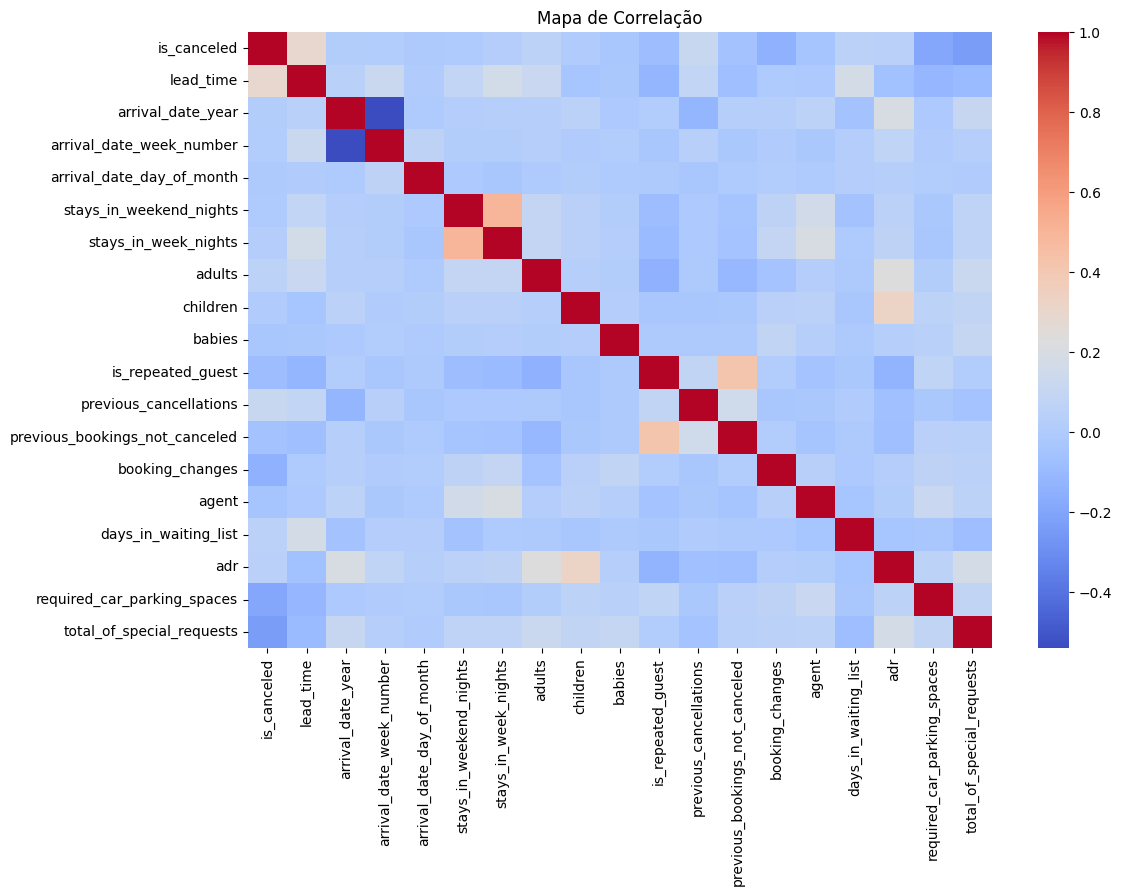

In [23]:
plt.figure(figsize=(12,8))

correlacao = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    correlacao,
    cmap="coolwarm",
    annot=False
)

plt.title("Mapa de Correlação")

plt.show()

### Interpretação

O mapa de calor permite identificar relações entre as variáveis numéricas. Essas informações auxiliam na escolha dos atributos utilizados pelo modelo de Machine Learning.

# Construção do Modelo de Machine Learning

Nesta etapa será desenvolvido um modelo de Machine Learning para prever o cancelamento de reservas.

Inicialmente serão preparadas as variáveis, realizadas as transformações necessárias e, posteriormente, treinado um modelo utilizando o algoritmo **Random Forest**, bastante utilizado em problemas de classificação.

In [24]:
# ============================================================
# PREPARAÇÃO DOS DADOS
# ============================================================

# Cópia do dataset
modelo = df.copy()

# Removendo coluna que gera vazamento de informação
modelo = modelo.drop(
    columns=[
        "reservation_status",
        "reservation_status_date"
    ]
)

# Transformação das variáveis categóricas
modelo = pd.get_dummies(modelo, drop_first=True)

print(modelo.shape)

(119390, 248)


In [25]:
# ============================================================
# VARIÁVEIS DE ENTRADA E SAÍDA
# ============================================================

X = modelo.drop("is_canceled", axis=1)

y = modelo["is_canceled"]

print(X.shape)
print(y.shape)

(119390, 247)
(119390,)


In [26]:
# ============================================================
# TREINO E TESTE
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(83573, 247)
(35817, 247)


In [34]:
# ============================================================
# RANDOM FOREST - CRIAÇÃO DO MODELO
# ============================================================

modelo_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

In [39]:
# ============================================================
# TREINAMENTO
# ============================================================

modelo_rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [28]:
# ============================================================
# PREVISÕES
# ============================================================

previsoes = modelo_rf.predict(X_test)

In [29]:
# ============================================================
# ACURÁCIA
# ============================================================

acuracia = accuracy_score(y_test, previsoes)

print(f"Acurácia: {acuracia:.2%}")

Acurácia: 89.52%


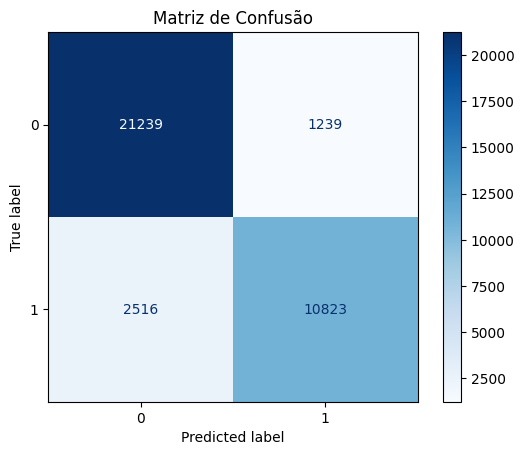

In [30]:
# ============================================================
# MATRIZ DE CONFUSÃO
# ============================================================

cm = confusion_matrix(y_test, previsoes)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap="Blues")

plt.title("Matriz de Confusão")

plt.show()

In [31]:
# ============================================================
# RELATÓRIO DE CLASSIFICAÇÃO
# ============================================================

print(classification_report(y_test, previsoes))

              precision    recall  f1-score   support

           0       0.89      0.94      0.92     22478
           1       0.90      0.81      0.85     13339

    accuracy                           0.90     35817
   macro avg       0.90      0.88      0.89     35817
weighted avg       0.90      0.90      0.89     35817



In [32]:
# ============================================================
# IMPORTÂNCIA DAS VARIÁVEIS
# ============================================================

importancias = pd.DataFrame({
    "Variável": X.columns,
    "Importância": modelo_rf.feature_importances_
})

importancias = importancias.sort_values(
    by="Importância",
    ascending=False
)

display(importancias.head(15))

,Variável,Importância
0,lead_time,0.107414
242,deposit_type_Non Refund,0.087204
168,country_PRT,0.070698
15,adr,0.069654
17,total_of_special_requests,0.056625
3,arrival_date_day_of_month,0.050949
2,arrival_date_week_number,0.045888
13,agent,0.043549
5,stays_in_week_nights,0.036171
10,previous_cancellations,0.031419


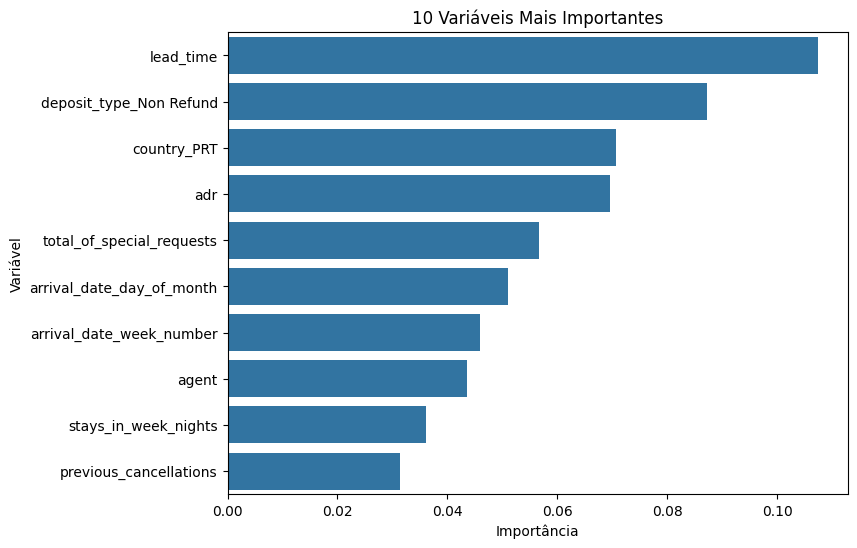

In [33]:
# ============================================================
# TOP 10 VARIÁVEIS MAIS IMPORTANTES
# ============================================================

plt.figure(figsize=(8,6))

sns.barplot(
    data=importancias.head(10),
    x="Importância",
    y="Variável"
)

plt.title("10 Variáveis Mais Importantes")

plt.show()

# Conclusão

O desenvolvimento deste projeto permitiu aplicar na prática conceitos fundamentais de Ciência de Dados e Machine Learning.

Durante o trabalho foram realizadas as etapas de exploração, tratamento e análise dos dados, permitindo compreender melhor o comportamento das reservas e os fatores relacionados ao cancelamento.

Na etapa de modelagem foi utilizado o algoritmo Random Forest, que apresentou bom desempenho na tarefa de classificação, demonstrando que técnicas de Inteligência Artificial podem auxiliar hotéis na previsão de cancelamentos e apoiar decisões estratégicas.

Além do desenvolvimento do modelo, o projeto proporcionou maior familiaridade com bibliotecas como Pandas, NumPy, Matplotlib, Seaborn e Scikit-Learn, consolidando conhecimentos importantes para futuros projetos na área de Inteligência Artificial e Ciência de Dados.

## Análise dos Resultados

O modelo Random Forest apresentou uma acurácia de **89,52%**, indicando um bom desempenho na classificação das reservas entre canceladas e não canceladas.

A matriz de confusão demonstrou que a maior parte das previsões foi realizada corretamente, enquanto o relatório de classificação apresentou métricas satisfatórias de precisão (*precision*), revocação (*recall*) e F1-score para ambas as classes.

Esses resultados demonstram que o modelo foi capaz de identificar padrões relevantes nos dados e pode ser utilizado como ferramenta de apoio para a previsão de cancelamentos de reservas.

Como trabalhos futuros, seria interessante comparar o Random Forest com outros algoritmos de classificação, realizar ajustes de hiperparâmetros e testar técnicas de balanceamento de dados para verificar se é possível obter um desempenho ainda melhor.

## Considerações sobre o desenvolvimento

Durante o desenvolvimento deste projeto ocorreram alguns desafios relacionados ao ambiente de execução, como a reinicialização da sessão do Google Colab e a necessidade de recarregar o conjunto de dados. Essas situações exigiram a reorganização do fluxo de trabalho e reforçaram a importância de validar cada etapa antes de prosseguir.

A experiência contribuiu para compreender melhor não apenas o processo de construção de um modelo de Machine Learning, mas também aspectos práticos relacionados ao gerenciamento do ambiente de desenvolvimento.